# Task 04 — Twitter Entity Sentiment Analysis

## 📌 Project Overview

This project analyzes Twitter social media data to understand sentiment
patterns and public opinion toward different entities and topics.

The analysis includes data cleaning, sentiment distribution,
entity-level sentiment analysis, text analysis, and visualization.

## 🎯 Objectives

- Analyze Positive, Negative, and Neutral sentiments
- Identify the most discussed entities
- Compare sentiment patterns across entities
- Find frequently used words in tweets
- Visualize sentiment patterns using charts and a word cloud

## 🛠️ Technologies Used

- Python
- Pandas
- Matplotlib
- WordCloud
- Google Colab

## 📊 Dataset

Twitter Entity Sentiment Analysis dataset containing tweets,
entities, and sentiment labels.

In [7]:
!wget -O twitter_training.csv https://raw.githubusercontent.com/lihkir/Data/main/twitter_training.csv

--2026-09-19 13:15:46--  https://raw.githubusercontent.com/lihkir/Data/main/twitter_training.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10250406 (9.8M) [text/plain]
Saving to: ‘twitter_training.csv’

twitter_training.cs 100%[===================>]   9.78M  --.-KB/s    in 0.09s   

2026-09-19 13:15:46 (112 MB/s) - ‘twitter_training.csv’ saved [10250406/10250406]



In [8]:
import pandas as pd

df = pd.read_csv('/content/twitter_training.csv', header=None)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (74682, 4)


,0,1,2,3
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [9]:
df.columns = ['ID', 'Entity', 'Sentiment', 'Tweet']

print(df.columns)
df.head()

Index(['ID', 'Entity', 'Sentiment', 'Tweet'], dtype='object')


,ID,Entity,Sentiment,Tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [10]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Missing values:
ID             0
Entity         0
Sentiment      0
Tweet        686
dtype: int64

Duplicate rows:
2700


In [11]:
# Remove rows where important information is missing
df = df.dropna(subset=['Entity', 'Sentiment', 'Tweet'])

# Remove duplicate rows
df = df.drop_duplicates()

# Remove unnecessary spaces from text columns
df['Entity'] = df['Entity'].astype(str).str.strip()
df['Sentiment'] = df['Sentiment'].astype(str).str.strip()
df['Tweet'] = df['Tweet'].astype(str).str.strip()

print("Dataset after cleaning:")
print("Rows and columns:", df.shape)

df.head()

Dataset after cleaning:
Rows and columns: (71656, 4)


,ID,Entity,Sentiment,Tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


Sentiment
Negative      21698
Positive      19713
Neutral       17708
Irrelevant    12537
Name: count, dtype: int64


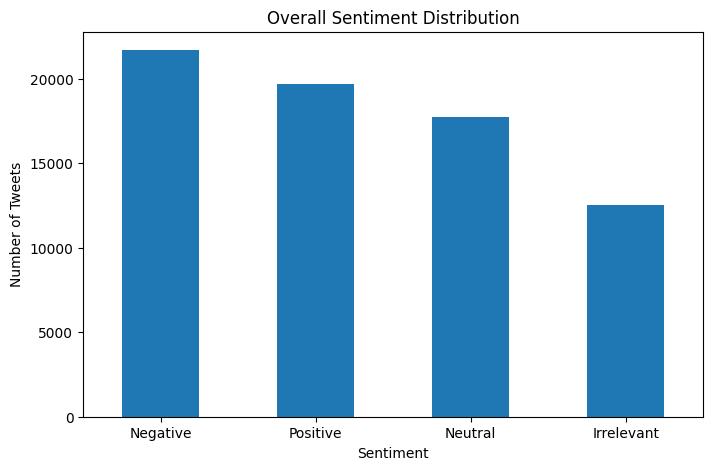

In [12]:
import matplotlib.pyplot as plt

# Count each sentiment
sentiment_counts = df['Sentiment'].value_counts()

print(sentiment_counts)

# Create the chart
plt.figure(figsize=(8, 5))
sentiment_counts.plot(kind='bar')

plt.title('Overall Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
plt.xticks(rotation=0)

plt.show()

In [13]:
# Count the number of tweets for each entity
entity_counts = df['Entity'].value_counts()

print("Top 10 most discussed entities:")
print(entity_counts.head(10))

Top 10 most discussed entities:
Entity
TomClancysRainbowSix    2328
Verizon                 2319
MaddenNFL               2315
CallOfDuty              2314
Microsoft               2304
WorldOfCraft            2300
NBA2K                   2299
LeagueOfLegends         2296
TomClancysGhostRecon    2291
Facebook                2289
Name: count, dtype: int64


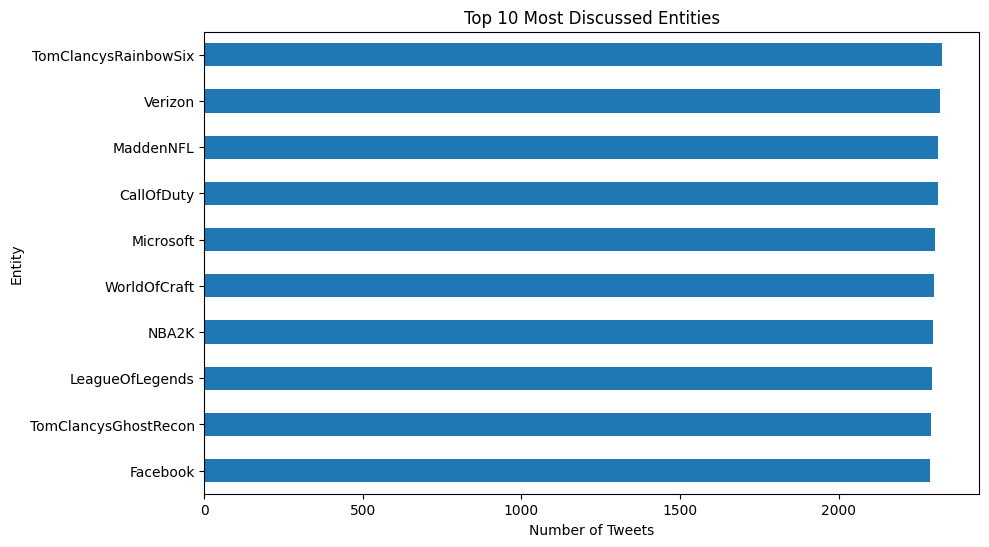

In [14]:
plt.figure(figsize=(10, 6))

entity_counts.head(10).sort_values().plot(kind='barh')

plt.title('Top 10 Most Discussed Entities')
plt.xlabel('Number of Tweets')
plt.ylabel('Entity')

plt.show()

In [15]:
# Create a table showing sentiment counts for each entity
entity_sentiment = pd.crosstab(
    df['Entity'],
    df['Sentiment']
)

# Select the 10 most discussed entities
top_entities = entity_counts.head(10).index
top_entity_sentiment = entity_sentiment.loc[top_entities]

print(top_entity_sentiment)

Sentiment             Irrelevant  Negative  Neutral  Positive
Entity                                                       
TomClancysRainbowSix          92      1110      628       498
Verizon                      177      1070      552       520
MaddenNFL                     86      1665      191       373
CallOfDuty                   660       861      367       426
Microsoft                    167       748      816       573
WorldOfCraft                 210       328     1047       715
NBA2K                        175      1450      265       409
LeagueOfLegends              298       616      800       582
TomClancysGhostRecon          23       887      776       605
Facebook                     672       690      773       154


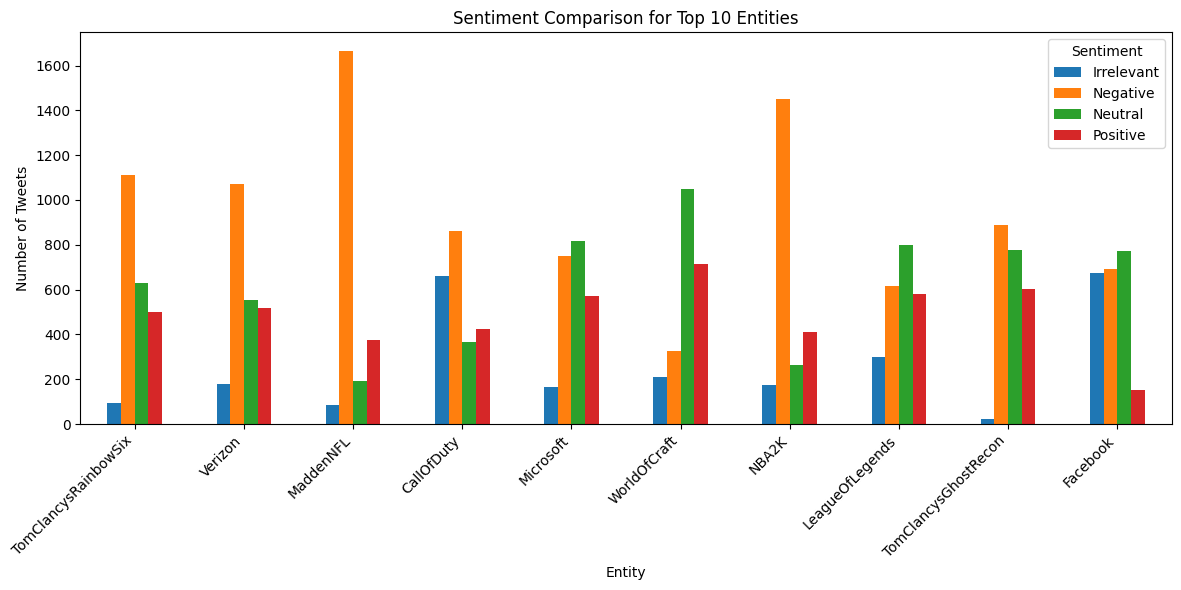

In [16]:
# Plot sentiment comparison for the top 10 entities

top_entity_sentiment.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Sentiment Comparison for Top 10 Entities')
plt.xlabel('Entity')
plt.ylabel('Number of Tweets')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sentiment')
plt.tight_layout()

plt.show()

In [17]:
# Calculate overall sentiment percentages
sentiment_percentage = df['Sentiment'].value_counts(normalize=True) * 100

print("Sentiment Percentage:")
print(sentiment_percentage.round(2))

Sentiment Percentage:
Sentiment
Negative      30.28
Positive      27.51
Neutral       24.71
Irrelevant    17.50
Name: proportion, dtype: float64


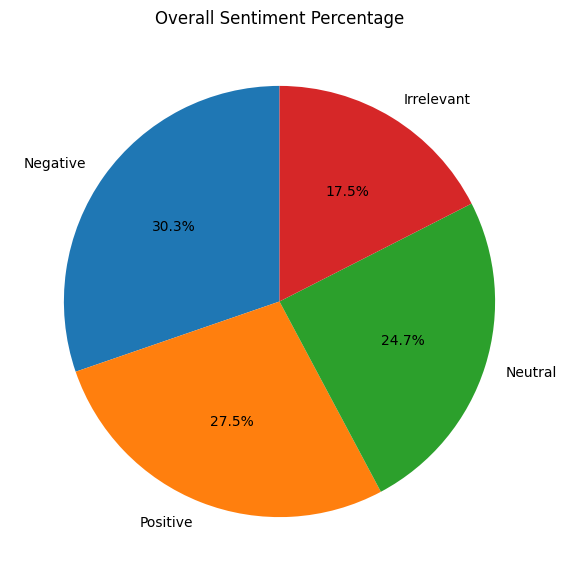

In [18]:
plt.figure(figsize=(7, 7))

sentiment_percentage.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Overall Sentiment Percentage')
plt.ylabel('')

plt.show()

In [19]:
# Calculate sentiment percentages for the top 10 entities

top_entity_percentage = (
    top_entity_sentiment
    .div(top_entity_sentiment.sum(axis=1), axis=0)
    * 100
)

print(top_entity_percentage.round(2))

Sentiment             Irrelevant  Negative  Neutral  Positive
Entity                                                       
TomClancysRainbowSix        3.95     47.68    26.98     21.39
Verizon                     7.63     46.14    23.80     22.42
MaddenNFL                   3.71     71.92     8.25     16.11
CallOfDuty                 28.52     37.21    15.86     18.41
Microsoft                   7.25     32.47    35.42     24.87
WorldOfCraft                9.13     14.26    45.52     31.09
NBA2K                       7.61     63.07    11.53     17.79
LeagueOfLegends            12.98     26.83    34.84     25.35
TomClancysGhostRecon        1.00     38.72    33.87     26.41
Facebook                   29.36     30.14    33.77      6.73


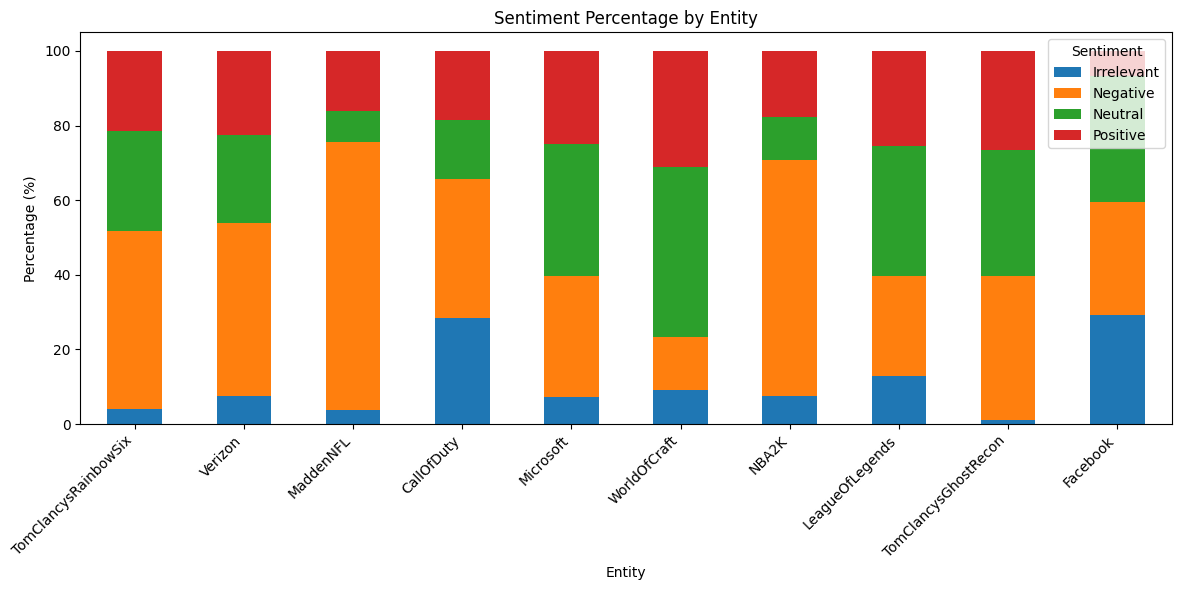

In [20]:
# Visualize sentiment percentages for the top 10 entities

top_entity_percentage.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6)
)

plt.title('Sentiment Percentage by Entity')
plt.xlabel('Entity')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sentiment')
plt.tight_layout()

plt.show()

In [21]:
import re

# Combine all tweets into one text
all_tweets = ' '.join(df['Tweet'].astype(str))

# Convert to lowercase
all_tweets = all_tweets.lower()

# Remove URLs, mentions, hashtags, numbers and punctuation
all_tweets = re.sub(r'http\S+|www\S+', '', all_tweets)
all_tweets = re.sub(r'@\w+', '', all_tweets)
all_tweets = re.sub(r'#\w+', '', all_tweets)
all_tweets = re.sub(r'\d+', '', all_tweets)
all_tweets = re.sub(r'[^a-z\s]', ' ', all_tweets)

# Remove extra spaces
all_tweets = re.sub(r'\s+', ' ', all_tweets).strip()

print(all_tweets[:1000])

im getting on borderlands and i will murder you all i am coming to the borders and i will kill you all im getting on borderlands and i will kill you all im coming on borderlands and i will murder you all im getting on borderlands and i will murder you me all im getting into borderlands and i can murder you all so i spent a few hours making something for fun if you don t know i am a huge fan and maya is one of my favorite characters so i decided to make myself a wallpaper for my pc here is the original image versus the creation i made enjoy pic twitter com mlsiwfjg so i spent a couple of hours doing something for fun if you don t know that i m a huge borderlands fan and maya is one of my favorite characters i decided to make a wallpaper for my pc here s the original picture compared to the creation i made have fun pic twitter com mlsiwfjg so i spent a few hours doing something for fun if you don t know i m a huge borderlands fan and maya is one of my favorite characters so i spent a few

In [22]:
from collections import Counter

# Split the cleaned text into individual words
words = all_tweets.split()

# Count word frequency
word_counts = Counter(words)

# Display the 20 most common words
print("Top 20 most common words:")
print(word_counts.most_common(20))

Top 20 most common words:
[('the', 44061), ('i', 35492), ('to', 28661), ('and', 26405), ('a', 24088), ('of', 19236), ('it', 17688), ('is', 17541), ('in', 15576), ('for', 15473), ('this', 14428), ('you', 12885), ('on', 11968), ('my', 11693), ('s', 11205), ('that', 11024), ('t', 9954), ('com', 9544), ('with', 8779), ('game', 8154)]


In [23]:
# Common English words to ignore
stop_words = {
    'the', 'and', 'is', 'to', 'of', 'a', 'in', 'for', 'on',
    'it', 'this', 'that', 'with', 'was', 'i', 'you', 'my',
    'me', 'be', 'are', 'have', 'has', 'had', 'but', 'not',
    'they', 'we', 'he', 'she', 'as', 'at', 'or', 'so',
    'from', 'an', 'if', 'by', 'about', 'can', 'just', 'im',
    'its', 'your', 'our', 'their'
}

# Remove stop words
filtered_words = [
    word for word in words
    if word not in stop_words and len(word) > 2
]

# Count the remaining words
filtered_word_counts = Counter(filtered_words)

print("Top 20 meaningful words:")
print(filtered_word_counts.most_common(20))

Top 20 meaningful words:
[('com', 9544), ('game', 8154), ('all', 6305), ('like', 4843), ('out', 4470), ('now', 4087), ('get', 3904), ('pic', 3804), ('twitter', 3727), ('one', 3599), ('good', 3480), ('play', 3399), ('what', 3375), ('will', 3291), ('new', 3237), ('when', 3232), ('really', 3218), ('love', 3170), ('unk', 3107), ('more', 3044)]


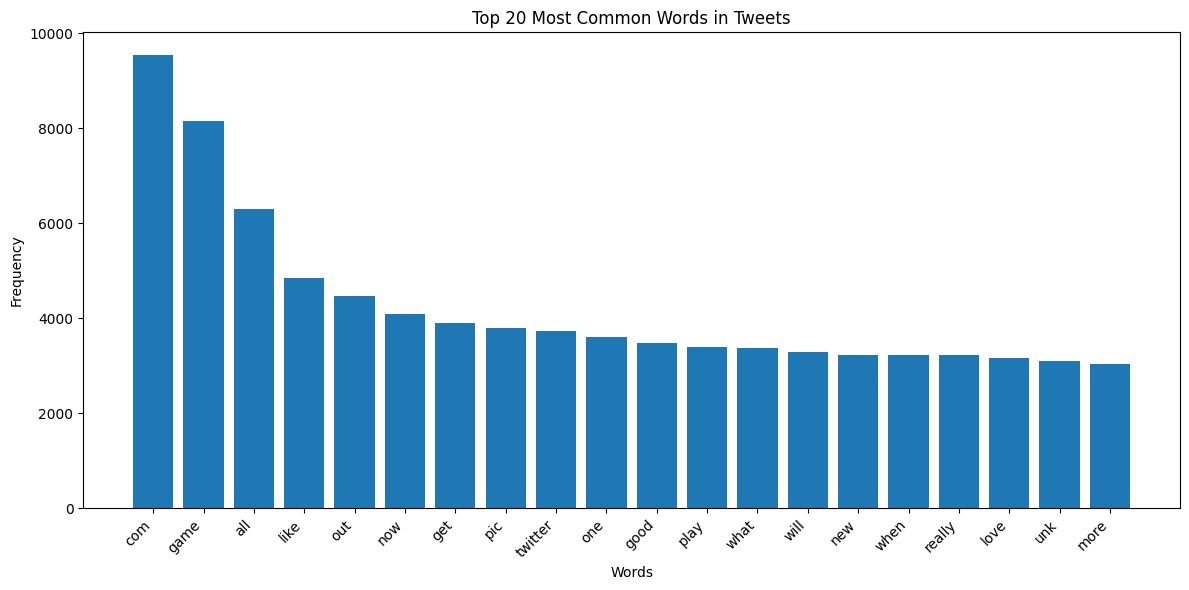

In [24]:
# Get the top 20 meaningful words
top_words = dict(filtered_word_counts.most_common(20))

# Create the bar chart
plt.figure(figsize=(12, 6))

plt.bar(top_words.keys(), top_words.values())

plt.title('Top 20 Most Common Words in Tweets')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

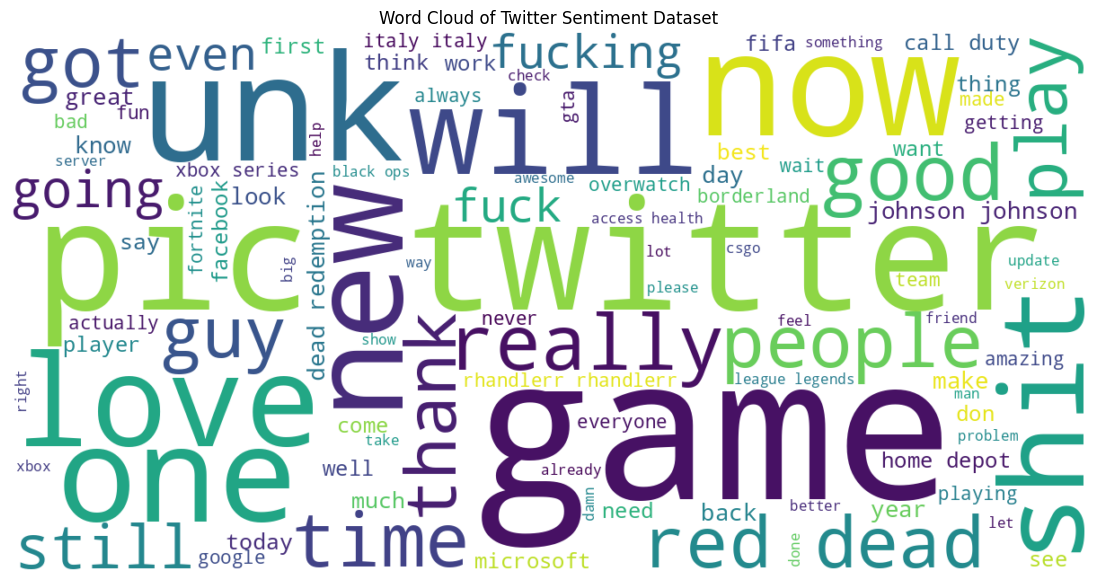

In [28]:
from wordcloud import WordCloud

# Create the word cloud
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    max_words=100
).generate(' '.join(filtered_words))

# Display the word cloud
plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Twitter Sentiment Dataset')

plt.show()

In [29]:
# Find the dominant sentiment for each entity

dominant_sentiment = entity_sentiment.idxmax(axis=1)

dominant_count = entity_sentiment.max(axis=1)

dominant_summary = pd.DataFrame({
    'Dominant Sentiment': dominant_sentiment,
    'Tweet Count': dominant_count
})

# Show the top 10 entities
dominant_summary.loc[top_entities]

,Dominant Sentiment,Tweet Count
Entity,,
TomClancysRainbowSix,Negative,1110
Verizon,Negative,1070
MaddenNFL,Negative,1665
CallOfDuty,Negative,861
Microsoft,Neutral,816
WorldOfCraft,Neutral,1047
NBA2K,Negative,1450
LeagueOfLegends,Neutral,800
TomClancysGhostRecon,Negative,887


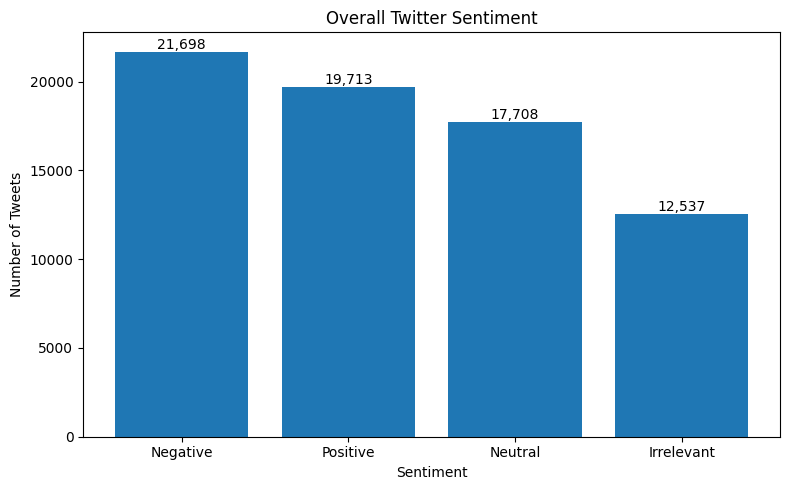

In [30]:
# Final sentiment summary chart

plt.figure(figsize=(8, 5))

bars = plt.bar(
    sentiment_counts.index,
    sentiment_counts.values
)

plt.title('Overall Twitter Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')

# Display values on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{int(height):,}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

In [31]:
# Generate key insights from the dataset

total_tweets = len(df)

print("========== TASK 04 - KEY INSIGHTS ==========\n")

print(f"Total tweets analyzed: {total_tweets:,}")

print("\nOverall Sentiment:")
for sentiment, count in sentiment_counts.items():
    percentage = (count / total_tweets) * 100
    print(f"- {sentiment}: {count:,} tweets ({percentage:.2f}%)")

print("\nTop 5 Most Discussed Entities:")
for entity, count in entity_counts.head(5).items():
    print(f"- {entity}: {count:,} tweets")

print("\nMost Common Words:")
for word, count in filtered_word_counts.most_common(10):
    print(f"- {word}: {count:,}")

========== TASK 04 - KEY INSIGHTS ==========

Total tweets analyzed: 71,656

Overall Sentiment:
- Negative: 21,698 tweets (30.28%)
- Positive: 19,713 tweets (27.51%)
- Neutral: 17,708 tweets (24.71%)
- Irrelevant: 12,537 tweets (17.50%)

Top 5 Most Discussed Entities:
- TomClancysRainbowSix: 2,328 tweets
- Verizon: 2,319 tweets
- MaddenNFL: 2,315 tweets
- CallOfDuty: 2,314 tweets
- Microsoft: 2,304 tweets

Most Common Words:
- com: 9,544
- game: 8,154
- all: 6,305
- like: 4,843
- out: 4,470
- now: 4,087
- get: 3,904
- pic: 3,804
- twitter: 3,727
- one: 3,599


In [32]:
# Create a clean sentiment summary table

summary_table = pd.DataFrame({
    'Sentiment': sentiment_counts.index,
    'Tweet Count': sentiment_counts.values,
    'Percentage': [
        round((count / total_tweets) * 100, 2)
        for count in sentiment_counts.values
    ]
})

summary_table

,Sentiment,Tweet Count,Percentage
0,Negative,21698,30.28
1,Positive,19713,27.51
2,Neutral,17708,24.71
3,Irrelevant,12537,17.50


In [33]:
print("""
========== CONCLUSION ==========

This project analyzed Twitter data to understand sentiment patterns
and public opinion toward different entities.

The analysis included:
1. Data cleaning and preprocessing
2. Overall sentiment distribution
3. Entity-level sentiment analysis
4. Sentiment percentage comparison
5. Most frequently used words
6. Word cloud visualization

The visualizations helped identify sentiment patterns and the topics
that appeared most frequently in the dataset.

This analysis demonstrates how data science and text analysis can be
used to extract meaningful insights from social media data.
""")


========== CONCLUSION ==========

This project analyzed Twitter data to understand sentiment patterns
and public opinion toward different entities.

The analysis included:
1. Data cleaning and preprocessing
2. Overall sentiment distribution
3. Entity-level sentiment analysis
4. Sentiment percentage comparison
5. Most frequently used words
6. Word cloud visualization

The visualizations helped identify sentiment patterns and the topics
that appeared most frequently in the dataset.

This analysis demonstrates how data science and text analysis can be
used to extract meaningful insights from social media data.

